# 2025년 07월 10일 목요일 (54일차)  



<br><br><br>

# 📜 목차  
- 주성분 분석 (PCA, Principal Component Analysis) 1
- 주성분 분석 (PCA, Principal Component Analysis) 2
- 군집분석 1
- 군집분석 2
- KFOLD 검증

<br><br><br>

## 🟢 주성분 분석 (PCA, Principal Component Analysis) 1

### 1. 주성분 분석이란 무엇인가요?
- 여러 **변수(열)**를 가지고 있는 복잡한 데이터를  
  **정보를 최대한 유지**하면서 **더 적은 수의 변수**로 압축하는 방법입니다.  
- 복잡한 사진 여러 장을 **요약본 한 장**으로 줄이는 것과 비슷합니다.

### 2. 왜 필요할까요?
| 상황 | PCA가 도움 되는 이유 |
|------|----------------------|
| 변수(특징)가 너무 많은 경우 | 계산 시간이 줄어듭니다. |
| 그래프로 보고 싶을 때 | 2차원‧3차원으로 변환해 쉽게 시각화할 수 있습니다. |
| 노이즈(잡음)가 많을 때 | 덜 중요한 정보를 줄여서 노이즈도 함께 감소합니다. |

### 3. 쉽게 이해하기
> “시험 과목이 국어‧수학‧영어가 있는데,  
>  성적표를 **‘종합 점수’ 하나**로 바꿔 보는 것”이라고 생각하시면 됩니다.

- 종합 점수가 **가장 많은 정보**(성적의 차이)를 담도록 계산합니다.  
- 이렇게 만든 첫 번째 점수를 **1번 주성분(PC1)**이라고 부릅니다.  
- 두 번째로 중요한 점수는 **2번 주성분(PC2)**, 이런 식으로 이어집니다.

### 4. 작동 순서 (아주 간단 버전)
1. **표준화**: 과목마다 점수 단위가 다르면 0~1 범위로 맞춥니다.  
2. **방향 찾기**: 점수가 **가장 많이 퍼진 방향**을 계산합니다.  
3. **투영**: 데이터를 그 방향(축)으로 옮겨서 새로운 점수를 만듭니다.  
4. **필요한 개수만 남기기**: 정보가 충분히 담겼다고 판단되는 상위 k개만 사용합니다.

### 5. 장점과 단점
#### 장점
- 데이터가 가벼워져서 **학습 속도**가 빨라집니다.  
- 2D‧3D로 줄이면 **눈으로 확인**하기 편합니다.

#### 단점
- 새로 만든 점수(주성분)는 **원래 과목**과 1:1로 대응되지 않아  
  “왜 이런 값이 나왔을까?” 해석이 어려울 수 있습니다.  
- **직선(선형) 관계**만 고려하므로 복잡한 곡선 패턴은 놓칠 수 있습니다.

### 6. 기억할 포인트 한 줄 요약
> “PCA는 **‘가장 중요한 방향’**만 남겨서  
>  데이터를 **간단하고 가볍게** 만들어 주는 마법의 압축 도구입니다.”

<br>

### 학습시간을 줄일 수 있다. 짧은 시간에 높은 학습효과를 가져온다.
  - 비지도 학습의 일종 -> 시각화
  - 분석을 할때, 상관관계를 확인한다. 상관계를 구한다.
  - 1에 가까우면 양의 상관관계를 시각화 (산포도행렬, scattermatrix)
  - 특성대 특성의 관계를 차트로 그리는 거라서 특성이 4개면 4 * 4 = 16
  - 특성이 30개면 30 * 30 = 900개 그려져야 한다.
  - 각 성분별로 히스토그램을 그리거나 히트맵을 활용한다.
  - 산포도, 히스토그램, 히트맵을 그려본다.

In [2]:
from sklearn.datasets import load_breast_cancer

#데이터를 악성과 양성으로 쪼개보자 
cancer = load_breast_cancer() 
cancer_data = cancer['data']
cancer_target = cancer['target']

# cancer 변수는 sklearn의 load_breast_cancer() 함수를 통해 불러온 유방암 데이터셋입니다.
# 이 데이터셋은 머신러닝 실습에서 자주 사용되는 예제 데이터로,
# 유방암 종양의 다양한 특성(특징 변수)들과 종양이 악성(malignant)인지 양성(benign)인지에 대한 타겟 값을 포함하고 있습니다.
# cancer 객체는 Bunch 타입으로, 딕셔너리와 비슷하게 key-value 쌍으로 데이터와 설명을 담고 있습니다.
print(type(cancer))
print(cancer.keys())
print(cancer['DESCR'])  # 데이터셋에 대한 설명 출력

# Bunch 타입은 sklearn에서 자주 사용하는 자료구조로, 파이썬의 딕셔너리와 비슷하지만
# 점(.) 표기법으로도 key에 접근할 수 있는 편리한 객체입니다.
# 예를 들어 cancer['data']와 cancer.data 모두 사용 가능합니다.
# 내부적으로는 다음과 같이 정의되어 있습니다.
from sklearn.utils import Bunch

# Bunch 예시
sample_bunch = Bunch(data=[1,2,3], target=[0,1,0], feature_names=['a','b','c'])
print(sample_bunch['data'])    # 딕셔너리 방식 접근
print(sample_bunch.data)       # 속성 방식 접근

# 즉, Bunch는 dict와 비슷하지만, 속성처럼 key에 접근할 수 있다는 점이 다릅니다.

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed 

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


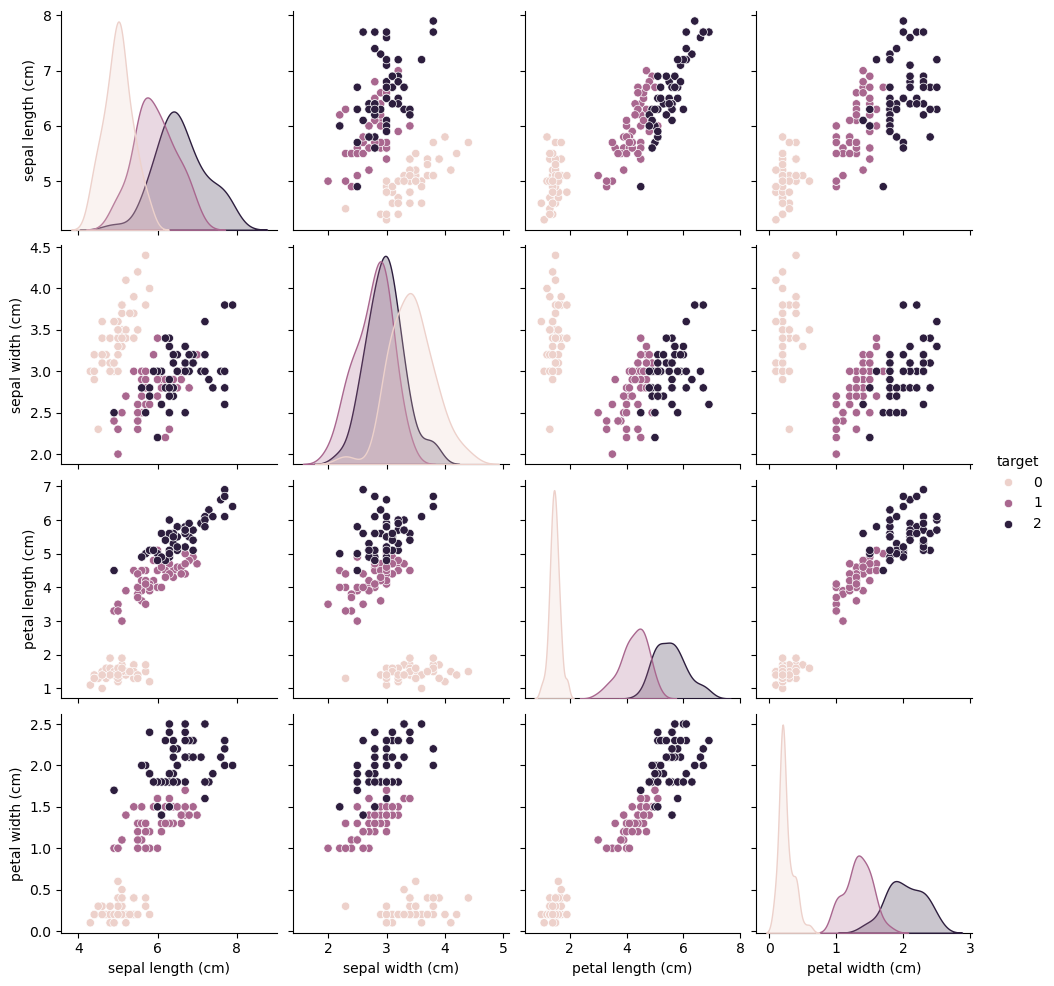

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd

iris = load_iris()
# Bunch => DataFrame
df1 = pd.DataFrame(iris.data, columns=iris.feature_names)
df1['target'] = iris.target
print(df1.head())


# seaborn 에서 산포도행렬(pairplot)
sns.pairplot(df1, hue='target')
# setoa, vesicolor, versinica 세가지 색상을 다르게 표현한다.
plt.show()  # 모든 그래픽 출력은 해줘야 한다.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

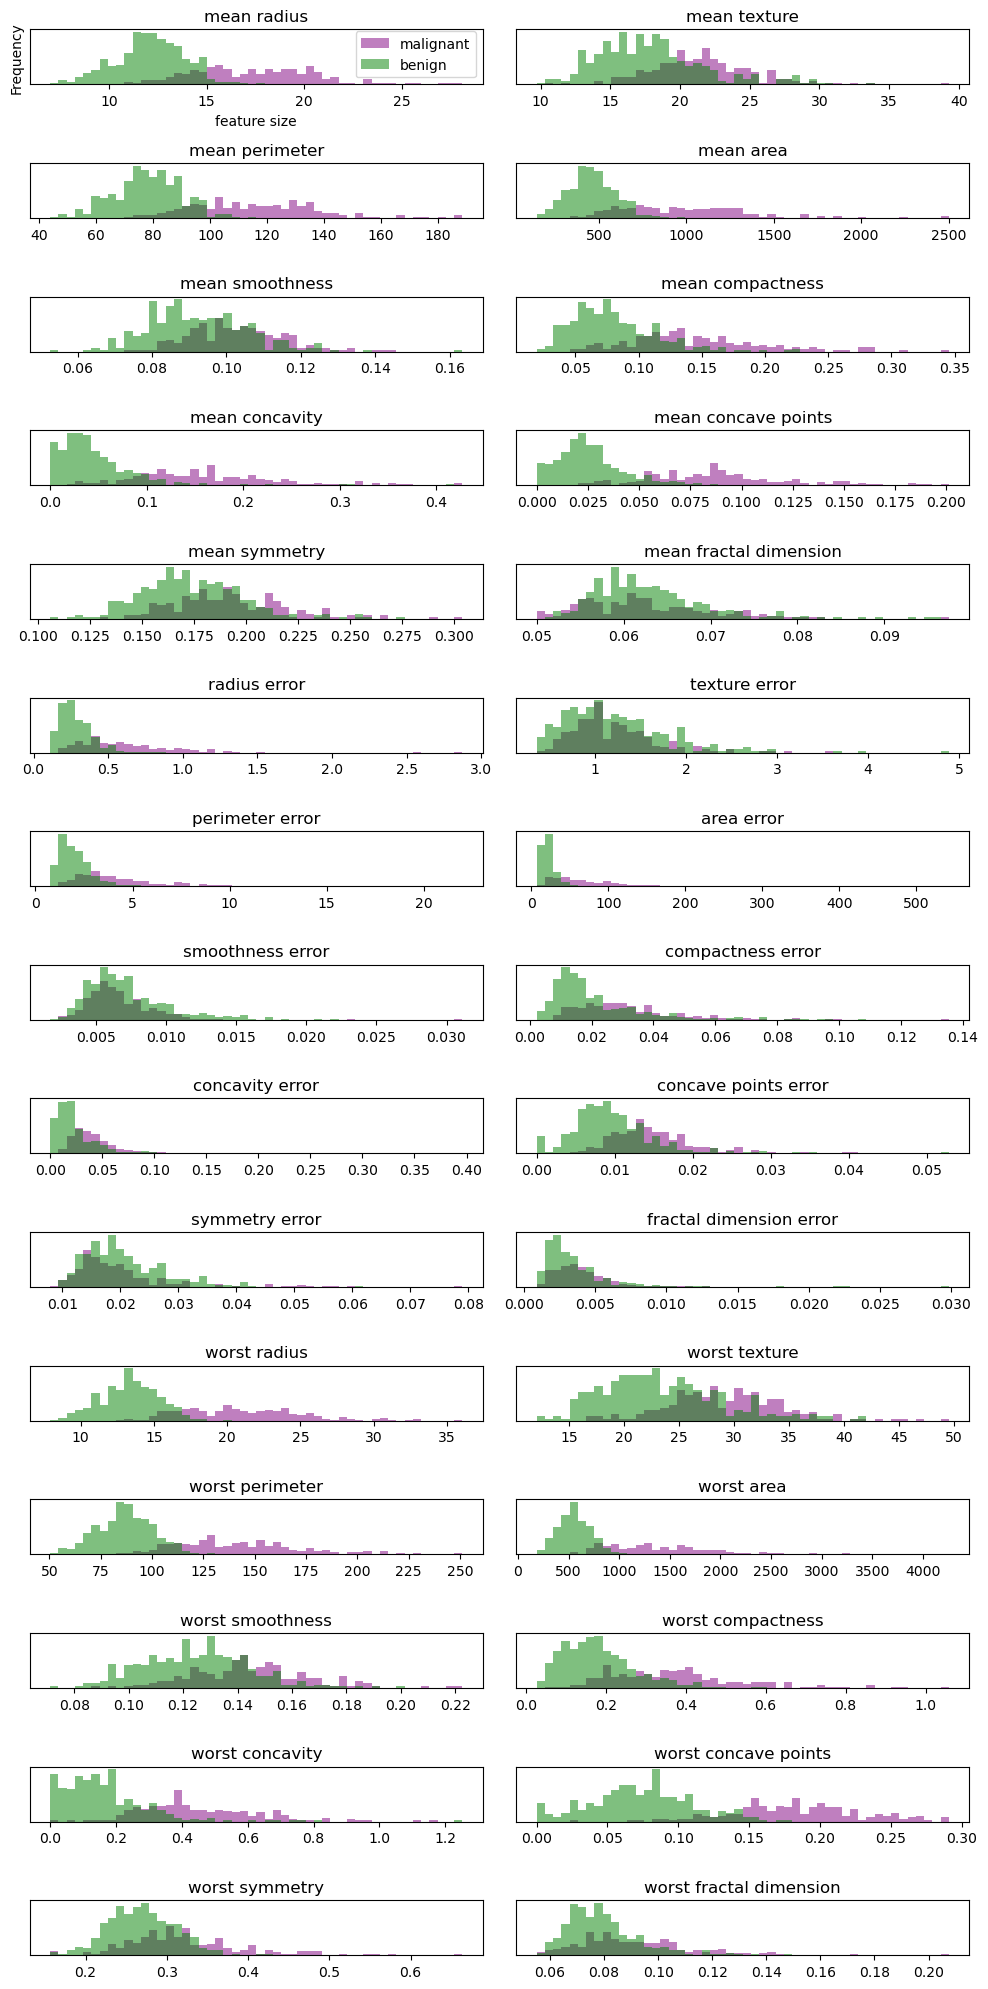

                        mean radius  mean texture  mean perimeter  mean area  \
mean radius                1.000000      0.323782        0.997855   0.987357   
mean texture               0.323782      1.000000        0.329533   0.321086   
mean perimeter             0.997855      0.329533        1.000000   0.986507   
mean area                  0.987357      0.321086        0.986507   1.000000   
mean smoothness            0.170581     -0.023389        0.207278   0.177028   
mean compactness           0.506124      0.236702        0.556936   0.498502   
mean concavity             0.676764      0.302418        0.716136   0.685983   
mean concave points        0.822529      0.293464        0.850977   0.823269   
mean symmetry              0.147741      0.071401        0.183027   0.151293   
mean fractal dimension    -0.311631     -0.076437       -0.261477  -0.283110   

                        mean smoothness  mean compactness  mean concavity  \
mean radius                    0.170581   

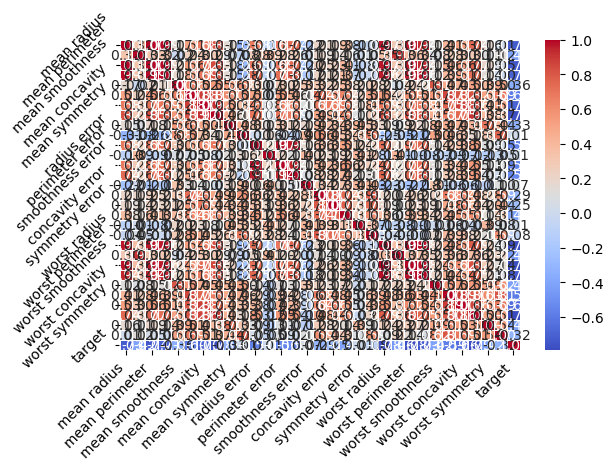

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer
import seaborn as sns
import pandas as pd

# iris = load_iris()
iris = load_breast_cancer()
df1 = pd.DataFrame(iris.data, columns=iris.feature_names)
df1['target'] = iris.target
print(df1.head())


# 특성이 많을 경우에 상관관계 시각화 - 히스토그램
# 악성과 악성 두개의 클래스를 갖는 데이터들의 집합 두 클래스별로 각자 데이터를 모아서 히스토그램을 그려보자
# 히스토그램이 특성의 개수만큼 나온다. 히스토그램이 데이터의 분포도를 확인 하기 좋은 차트다.
# 구간을 나눠서 => 히스토그램을 그려보자!

# 데이터를 악성과 양성으로 쪼개보자
cancer = load_breast_cancer()
cancer_data = cancer['data']
cancer_target = cancer['target']

# 악성끼리 모아보자!
malignant = cancer_data[cancer_target == 0]
benign = cancer_data[cancer_target == 1]
print(malignant.shape)
print(benign.shape)

# 히스토그램을 30개를 그려보자!
# 차트 안에 작은 차트를 계속 만든다. 15 by 2 로 나눠서 각각의 공간에 차트 하ㅏ만 
# 반환값이 차트자체와 축에 대한 정보, figsize=(10, 20) 차트 전체의 크기 width, height inch 단위
fig, axes = plt.subplots(15, 2, figsize=(10, 20))
import numpy as np
ax = axes.ravel()   # 축에 대한 정보를 가져온다.
for i in range(30):
    count, bins = np.histogram(cancer_data[:, i], bins=50)  # i 번째 열에 대해서 구간을 50개로 나눠라
    # count 각 구간별 데이터 개수

    # bins 구간리스트
    ax[i].hist(malignant[:, i], bins=bins, color='purple', alpha=0.5) # 악성데이터를 보라색으로
    ax[i].hist(benign[:, i], bins=bins, color='green', alpha=0.5) # 양성데이터를 녹색으로
    
    # 제목
    ax[i].set_title(cancer['feature_names'][i])
    ax[i].set_yticks(()) # y축 눈금 제거

ax[0].set_xlabel('feature size')
ax[0].set_ylabel('Frequency')
ax[0].legend(['malignant', 'benign'], loc='best')
fig.tight_layout()  # 차트 정렬하기
plt.show()

# 히트맵 산포도행렬 못 그릴 때 자주 사용하는 차트이다. - 상관관계를 확인할 수 있다.
# 1. 상관관계 행렬 만들기
correlation_matrix = df1.corr() # 데이터 프레임이 corr이라는 함수가 있어서 상관계수를 계산한다.
print(correlation_matrix[:10])

# 신기술 - plotly - Rd언어에 있던거가 파이썬에 들어옴
# fastAPI : 풀스텍 개발 - 프론트랑 백엔드를 쪼개 창고에서 html, css, js 가 독립


#2. 히트맵그리기
annot=True #차트에 줄 속성, 히트맵의 셀에 값을 표시한다. False면 표시안함
cmap = 'coolwarm' #히트맵에서 가장 많이 사용하는 색상 양의관계는 빨간색, 음의관계는 파란색
fmt = '.2f' #표시될 숫자의 소수점 자리수 지정
sns.heatmap(correlation_matrix,
            annot=annot, cmap=cmap, fmt=fmt,
            linewidths=.5 ) #셀사이에 선추가

plt.xticks(rotation=45, ha='right')  # x축 레이블 회전
plt.yticks(rotation=45, ha='right')  # y축 레이블 회전
plt.tight_layout()  # 차트 정렬하기
plt.show()
